In [45]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd
import scipy
import PIL
import requests


In [7]:
# Using pandas to read in the excel file and creating a dataframe to be able to call the columns

funding_data = pd.read_excel("research_funding_summary_current_2018-2026_updated_en.xlsx", sheet_name=1)
funding_data.head()

,Program,Round,Project Number,Project Title,Project Description,Field of Research (FOR) - Level 1 Division Code,FOR - Level 1 Division Title,FOR - Level 2 Group Code,FOR - Level 2 Group Title,FOR - Level 3 Class Code,...,Fiscal Year,Ontario Commitment,Total Project Costs,Salutation,First Name,Middle Name,Last Name,Expenditure Type,Language,Keywords
0,Ontario Research Fund - Research Excellence,Disruptive Innovation in Genomics - Round 002,14401,AbSyn Technology for Identification of Synergi...,"AbSyn is a unique, Ontario-made platform that ...",4.2,Preventive medicine,NaN,NaN,42800,...,2018-19,637573.0,2719453.0,NaN,Jason,NaN,Moffat,Operating,English,"functional genetics, cancer therapeutics"
1,Ontario Research Fund - Research Excellence,Disruptive Innovation in Genomics - Round 002,14405,RapidAIM: A technology to rapidly assess the e...,Develop the first fully automated high through...,4.2,Preventive medicine,NaN,NaN,41400,...,2018-19,756564.0,2888563.0,NaN,Daniel,NaN,Figeys,Operating,English,microbiome
2,Ontario Research Fund - Research Excellence,Disruptive Innovation in Genomics - Round 002,14407,Beyond the Genome: Transcriptome Based Diagnos...,We will create a RNA based diagnostic platform...,4.2,Preventive medicine,NaN,NaN,42700,...,2018-19,999553.0,2999944.0,NaN,Adam,NaN,Shlien,Operating,English,"diagnostics, rare diseases, cancer"
3,Ontario Research Fund - Research Excellence,Disruptive Innovation in Genomics - Round 002,14408,Interactome mapping of disease-related protein...,"We will develop a high-throughput, universal m...",4.2,Preventive medicine,NaN,NaN,40900,...,2018-19,725801.0,2223117.0,NaN,Igor,NaN,Stagljar,Operating,English,"protein interactome, drug-screening, cancer-re..."
4,Ontario Research Fund - Research Excellence,Disruptive Innovation in Genomics - Round 002,14409,Development of a digital microfluidic platform...,We are developing a new digital microfluidic t...,4.1,"Medical research, hospital treatment, surgery",NaN,NaN,41700,...,2018-19,1000000.0,3062970.0,NaN,Aaron,NaN,Wheeler,Operating,English,prenatal genetic test


In [18]:
# Filtering down to only the columns of the dataframe that I need to make a comparison between the amount of money each city recieves and which institutions
# are getting the funding from the government
funding_data = funding_data[['Lead Research Institution','City', 'Ontario Commitment']]

# Inspecting some of the rows and columns, there are duplicate names that appear when grouping. The following code will standardize the names
funding_data['City'] = funding_data['City'].str.strip()
funding_data['Lead Research Institution'] = funding_data['Lead Research Institution'].str.strip()



In [38]:
# Adding up all the totals for each lead research institution and the city the funding is going to. Then setting a limit to show only those universities that have received more than 10,000,000
# in funding over the course of 2018-2026
funding_by_institution = (funding_data.groupby(['Lead Research Institution','City'])['Ontario Commitment'].sum().reset_index())
funding_by_institution = funding_by_institution[funding_by_institution['Ontario Commitment'] >= 10000000]

In [ ]:
# This cell creates a pivot table that will stack each of the university or organization recieving funding with the city where the money is to be used
pivot = funding_by_institution.pivot(
    index='City',
    columns='Lead Research Institution',
    values='Ontario Commitment'
).fillna(0)

pivot['Total'] = pivot.sum(axis=1)

pivot = pivot.sort_values(
    by='Total',
    ascending=False
)

pivot = pivot.drop(columns='Total')

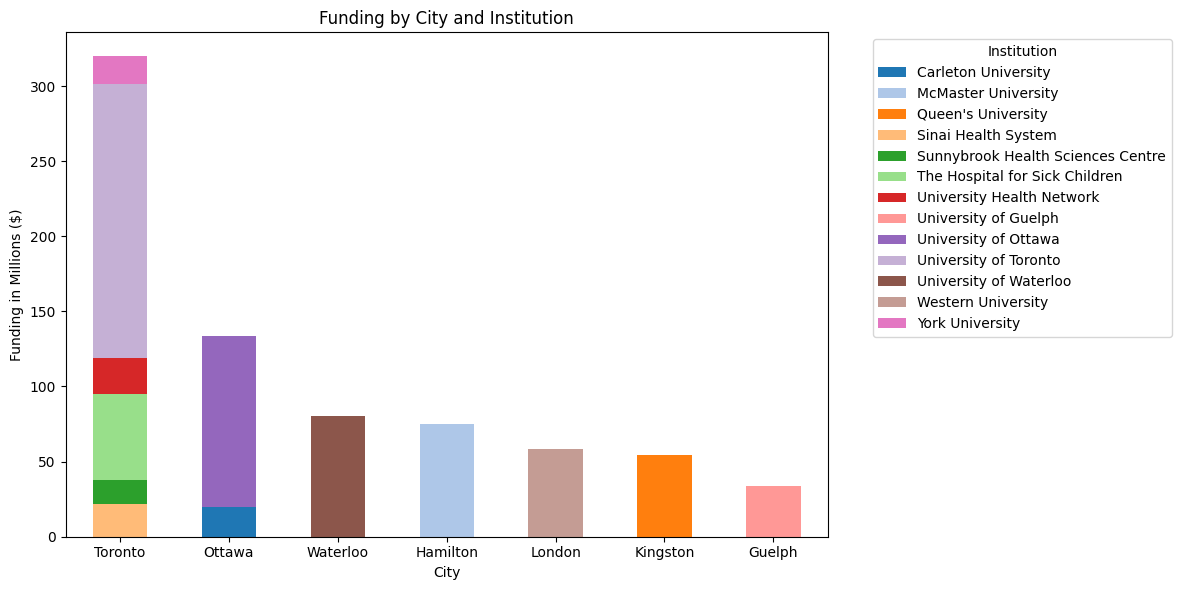

In [ ]:
# Main code that is actually creating the figure. I first use distinct colours, and create an axis using a pivot plot and stacked bar chart. There are a number of parameters
# that are specified for all of the axes for how the data is displayed. 
distinct_colors = plt.cm.tab20.colors

ax = pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=distinct_colors
)

fig = ax.get_figure()

ax.tick_params(axis='x',rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x * 1e-6:.0f}"))
ax.set_title('Funding by City and Institution')
ax.set_xlabel('City')
ax.set_ylabel('Funding in Millions ($)')
ax.legend(title='Institution',
          bbox_to_anchor=(1.05, 1),
          loc='upper left')

plt.tight_layout()

fig.savefig('Visulization 1: Funding by City and Institution')
plt.show()

